Script 3: Load Dataset

In [1]:
import pandas as pd
df = pd.read_csv("Labels.csv")

print("Dataset successfully loaded.\n")
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset shape:")
print(df.shape)
print("\nColumn names:")
print(df.columns)


Dataset successfully loaded.

First 5 rows of the dataset:
  Image Name  Patient Label  Quality Score  Unnamed: 4
0    0_0.jpg        0  GON+           6.18         NaN
1    1_0.jpg        1  GON+           5.31         NaN
2    1_1.jpg        1  GON+           4.37         NaN
3    2_0.jpg        2  GON+           3.51         NaN
4    2_1.jpg        2  GON+           4.24         NaN

Dataset shape:
(747, 5)

Column names:
Index(['Image Name', 'Patient', 'Label', 'Quality Score', 'Unnamed: 4'], dtype='object')


Script 4: Label Distribution

In [2]:
import pandas as pd
 
df = pd.read_csv("Labels.csv")
 
print("Label distribution:\n")
print(df["Label"].value_counts())


Label distribution:

Label
GON+    548
GON-    199
Name: count, dtype: int64


Script 5: Patient Analysis

In [3]:
import pandas as pd
 
df = pd.read_csv("Labels.csv")
 
print("Total number of images:")
print(len(df))
print("\nTotal unique patients:")
print(df["Patient"].nunique())
print("\nImages per patient:")
print(df.groupby("Patient").size().head())


Total number of images:
747

Total unique patients:
288

Images per patient:
Patient
0    1
1    2
2    2
3    2
4    1
dtype: int64


Script 6: Quality Analysis

In [4]:
import pandas as pd
 
df = pd.read_csv("Labels.csv")
 
print("Quality score statistics:\n")
print(df["Quality Score"].describe())


Quality score statistics:

count    747.000000
mean       5.904311
std        1.007189
min        2.040000
25%        5.365000
50%        6.180000
75%        6.630000
max        7.690000
Name: Quality Score, dtype: float64


Script 7: Plot Labels

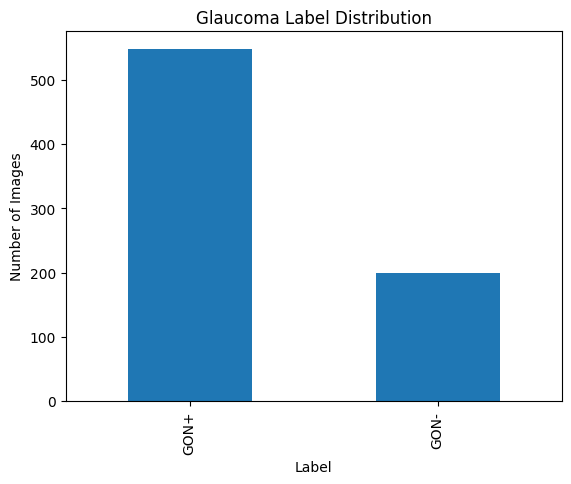

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
 
df = pd.read_csv("Labels.csv")
 
label_counts = df["Label"].value_counts()
label_counts.plot(kind="bar")
plt.title("Glaucoma Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Images")
plt.show()


Script 8: Create Image Paths

In [6]:
import pandas as pd
import os

# Load the dataset
df = pd.read_csv("Labels.csv")

# Remove unncessary columns
"Unnamed: 4" in df.columns and df.drop(columns=["Unnamed: 4"], inplace=True)

# Define image folder
image_folder = "Images"

# Create full image path
df['Image_Path'] = df["Image Name"].apply(
    lambda x: os.path.join(image_folder, x)
)

print("Dataset  with image paths:\n")
print(df.head())

Dataset  with image paths:

  Image Name  Patient Label  Quality Score      Image_Path
0    0_0.jpg        0  GON+           6.18  Images/0_0.jpg
1    1_0.jpg        1  GON+           5.31  Images/1_0.jpg
2    1_1.jpg        1  GON+           4.37  Images/1_1.jpg
3    2_0.jpg        2  GON+           3.51  Images/2_0.jpg
4    2_1.jpg        2  GON+           4.24  Images/2_1.jpg


Script 9: Check Images

In [7]:
import pandas as pd
import os
 
df = pd.read_csv("Labels.csv")
if "Unnamed: 4" in df.columns:
    df = df.drop(columns=["Unnamed: 4"])
 
image_folder = "images"
df["image_path"] = df["Image Name"].apply(
    lambda x: os.path.join(image_folder, x)
)
 
# Check if image exists
df["file_exists"] = df["image_path"].apply(os.path.exists)
 
print("Image file check summary:\n")
print(df["file_exists"].value_counts())


Image file check summary:

file_exists
True    747
Name: count, dtype: int64


Script 10: Load image

In [8]:
import pandas as pd
from PIL import Image
import os
 
df = pd.read_csv("Labels.csv")
if "Unnamed: 4" in df.columns:
    df = df.drop(columns=["Unnamed: 4"])
df["image_path"] = df["Image Name"].apply(
    lambda x: os.path.join("images", x)
)
 
# Select first image
image_path = df.iloc[0]["image_path"]
img = Image.open(image_path)
 
print("Image path:", image_path)
print("Image size:", img.size)
print("Image mode:", img.mode)


Image path: images/0_0.jpg
Image size: (1918, 1918)
Image mode: RGB


Script 11: Display retinal image

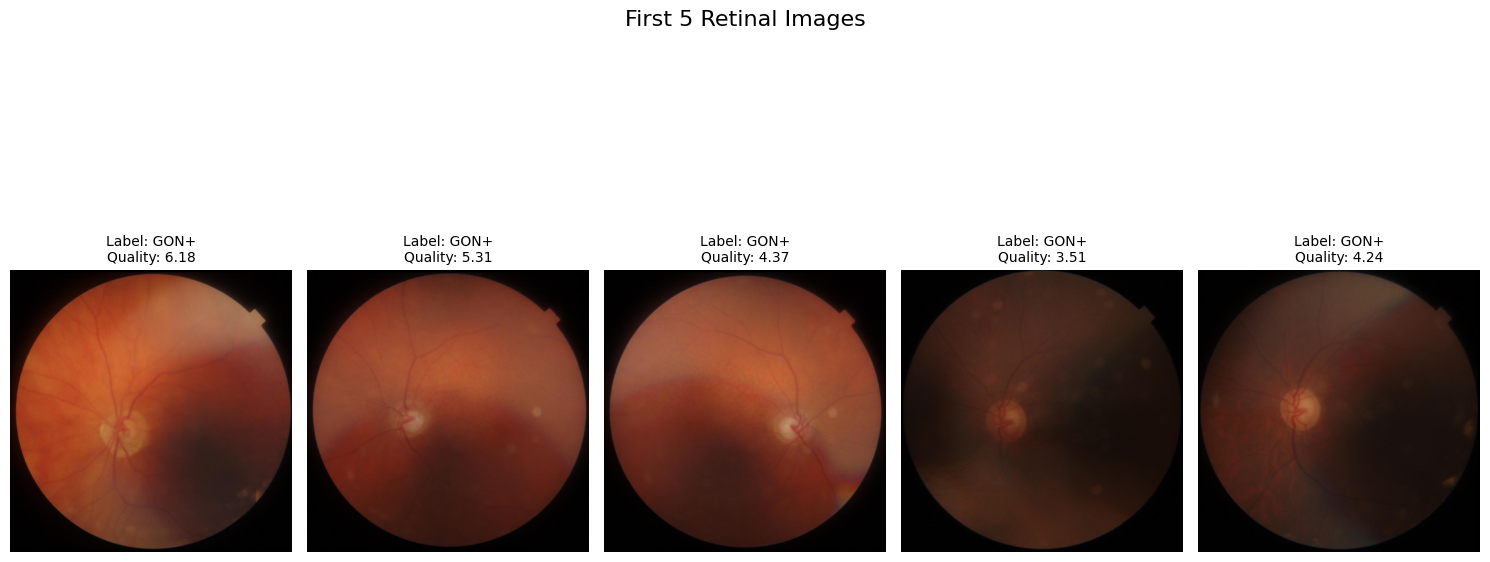

Displayed the first 5 retinal images.
Observe the optic disc, retinal vessels, illumination variation, blur, and noise.
These factors can affect image quality and model performance.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("Labels.csv")

# Remove unnecessary column if present
if "Unnamed: 4" in df.columns:
 df.drop(columns=["Unnamed: 4"], inplace=True)

# ===============================
# 2. CREATE IMAGE PATH
# ===============================
image_folder = "images"
df["image_path"] = df["Image Name"].apply(lambda x: os.path.join(image_folder, x))

# ===============================
# 3. CHECK REQUIRED COLUMNS
# ===============================
required_columns = ["Image Name", "Label", "image_path"]
for col in required_columns:
 if col not in df.columns:
    raise ValueError(f"Required column '{col}' not found in dataset.")

# Check whether quality score column exists
quality_col = None
possible_quality_cols = ["Quality Score", "quality_score", "Quality", "quality"]
for col in possible_quality_cols:
 if col in df.columns:
    quality_col = col
    break

# ===============================
# 4. DISPLAY FIRST 5 IMAGES
# ===============================
num_images = min(5, len(df))
plt.figure(figsize=(15, 8))

for i in range(num_images):
 row = df.iloc[i]
 img_path = row["image_path"]
 label = row["Label"]

 if quality_col is not None:
    quality_score = row[quality_col]
    title_text = f"Label: {label}\nQuality: {quality_score}"
 else:
    title_text = f"Label: {label}\nQuality: N/A"

 plt.subplot(1, num_images, i + 1)

 if os.path.exists(img_path):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(title_text, fontsize=10)
    plt.axis("off")
 else:
    plt.text(0.5, 0.5, "Image\nNot Found", ha="center", va="center",
fontsize=12)
    plt.title(title_text, fontsize=10)
    plt.axis("off")

plt.suptitle("First 5 Retinal Images", fontsize=16)
plt.tight_layout()
plt.show()

# ===============================
# 5. LEARNING MESSAGE
# ===============================
print("Displayed the first 5 retinal images.")
print("Observe the optic disc, retinal vessels, illumination variation, blur, and noise.")
print("These factors can affect image quality and model performance.")   


Script 12: Check Image Sizes

In [10]:
import pandas as pd 
from PIL import Image 
import os 
 
# =============================== 
# 1. LOAD DATASET 
# =============================== 
df = pd.read_csv("Labels.csv") 
 
# Remove unnecessary column if present 
if "Unnamed: 4" in df.columns: 
    df.drop(columns=["Unnamed: 4"], inplace=True) 
 
# =============================== 
# 2. CREATE IMAGE PATH 
# =============================== 
image_folder = "Images" 
df["image_path"] = df["Image Name"].apply(lambda x: os.path.join(image_folder, x)) 
 
# =============================== 
# 3. CHECK FIRST 20 IMAGE SIZES 
# =============================== 
image_sizes = [] 
 
for img_path in df["image_path"].head(20): 
    if os.path.exists(img_path): 
        with Image.open(img_path) as img: 
            image_sizes.append(img.size)   # (width, height) 
    else: 
        image_sizes.append("Missing") 
 
# =============================== 
# 4. DISPLAY RESULTS 
# =============================== 
print("First 20 image sizes:\n") 
print(image_sizes) 
# =============================== 
# 5. OPTIONAL: UNIQUE SIZE SUMMARY 
# =============================== 
unique_sizes = set([s for s in image_sizes if s != "Missing"]) 
print("\nUnique image sizes detected:") 
print(unique_sizes)

First 20 image sizes:

['Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing']

Unique image sizes detected:
set()


Script 13: Encode labels

In [12]:
import pandas as pd
df = pd.read_csv("Labels.csv")
if "Unnamed: 4" in df.columns:
        df = df.drop(columns=["Unnamed: 4"])

label_map = {
        "GON+":1,
        "GON-":0
}

df["label_numeric"] = df["Label"].map(label_map)
print(df.head())

  Image Name  Patient Label  Quality Score  label_numeric
0    0_0.jpg        0  GON+           6.18              1
1    1_0.jpg        1  GON+           5.31              1
2    1_1.jpg        1  GON+           4.37              1
3    2_0.jpg        2  GON+           3.51              1
4    2_1.jpg        2  GON+           4.24              1


Script 14: Resize images

In [13]:
import pandas as pd 
import os 
from PIL import Image 
# Load dataset 
df = pd.read_csv("Labels.csv") 
if "Unnamed: 4" in df.columns: 
    df = df.drop(columns=["Unnamed: 4"]) 
image_folder = "images" 
resized_folder = "images_resized" 
if not os.path.exists(resized_folder): 
    os.makedirs(resized_folder) 
  
# Resize images 
for index, row in df.iterrows(): 
    image_path = os.path.join(image_folder, row["Image Name"]) 
    img = Image.open(image_path) 
    img = img.resize((224, 224)) 
    save_path = os.path.join(resized_folder, row["Image Name"]) 
    img.save(save_path) 
  
print("All images resized successfully.") 

All images resized successfully.


Script 15: Prepare image array

In [14]:
import pandas as pd 
import numpy as np 
import os 
from PIL import Image 
  
df = pd.read_csv("Labels.csv") 
if "Unnamed: 4" in df.columns: 
    df = df.drop(columns=["Unnamed: 4"]) 
  
image_folder = "images_resized" 
label_map = {"GON+": 1, "GON-": 0} 
  
images = [] 
labels = [] 
  
for index, row in df.iterrows(): 
    image_path = os.path.join(image_folder, row["Image Name"]) 
    img = Image.open(image_path) 
    img_array = np.array(img) / 255.0 
    images.append(img_array) 
    labels.append(label_map[row["Label"]]) 
  
images = np.array(images) 
labels = np.array(labels) 
  
print("Image dataset shape:", images.shape) 
print("Label dataset shape:", labels.shape)

Image dataset shape: (747, 224, 224, 3)
Label dataset shape: (747,)


Script 16: Filter Quality

In [15]:
import pandas as pd
 
df = pd.read_csv("Labels.csv")
if "Unnamed: 4" in df.columns:
    df = df.drop(columns=["Unnamed: 4"])
 
filtered_df = df[df["Quality Score"] >= 5]
 
print("Original dataset size:", len(df))
print("Filtered dataset size:", len(filtered_df))


Original dataset size: 747
Filtered dataset size: 618


Script 17: Save Clean Dataset

In [16]:
import pandas as pd 
  
df = pd.read_csv("Labels.csv") 
if "Unnamed: 4" in df.columns: 
    df = df.drop(columns=["Unnamed: 4"]) 
    df["label_numeric"] = df["Label"].map({"GON+": 1, "GON-": 0}) 
df.to_csv("glaucoma_clean_dataset.csv", index=False) 
print("Clean dataset saved.")



Clean dataset saved.


Script 18: Train Test Split

In [17]:
import pandas as pd 
from sklearn.model_selection import train_test_split 
  
df = pd.read_csv("Labels.csv") 
if "Unnamed: 4" in df.columns: 
    df = df.drop(columns=["Unnamed: 4"]) 
  
df["label_numeric"] = df["Label"].map({"GON+": 1, "GON-": 0}) 
  
# Get unique patient IDs 
patients = df["Patient"].unique() 
  
# Split patients into train/test 
train_patients, test_patients = train_test_split( 
    patients, 
    test_size=0.2, 
    random_state=42 
) 
  
# Select images belonging to those patients 
train_df = df[df["Patient"].isin(train_patients)] 
test_df = df[df["Patient"].isin(test_patients)] 
  
print("Training images:", len(train_df)) 
print("Testing images:", len(test_df)) 
print("Training patients:", train_df["Patient"].nunique()) 
print("Testing patients:", test_df["Patient"].nunique()) 
train_df.to_csv("train_dataset.csv", index=False) 
test_df.to_csv("test_dataset.csv", index=False) 
print("Datasets saved successfully.") 

Training images: 615
Testing images: 132
Training patients: 230
Testing patients: 58
Datasets saved successfully.


Script 19: Check split distribution

In [18]:
import pandas as pd
train_df = pd.read_csv("train_dataset.csv")
test_df = pd.read_csv("test_dataset.csv")
print("Training label distribution:")
print(train_df["Label"].value_counts())
print("\nTesting label distribution:")
print(test_df["Label"].value_counts())

Training label distribution:
Label
GON+    449
GON-    166
Name: count, dtype: int64

Testing label distribution:
Label
GON+    99
GON-    33
Name: count, dtype: int64


Script 20: Verify paths

In [19]:
import pandas as pd 
import os 
 
# =============================== 
# 1. LOAD DATASET 
# =============================== 
df = pd.read_csv("train_dataset.csv") 
 
# =============================== 
# 2. DEFINE IMAGE FOLDER 
# =============================== 
image_folder = "images_resized" 
 
# =============================== 
# 3. VERIFY IMAGE PATHS 
# =============================== 
missing_images = [] 
 
for img_name in df["Image Name"]: 
    img_path = os.path.join(image_folder, img_name) 
 
    if not os.path.exists(img_path): 
        missing_images.append(img_name) 
 
# =============================== 
# 4. REPORT RESULTS 
# =============================== 
total_images = len(df) 
missing_count = len(missing_images) 
 
print("Total images checked:", total_images) 
print("Missing images:", missing_count) 
 
if missing_count > 0: 
    print("\nMissing image files:") 
    for img in missing_images[:20]:   # show first 20 only 
        print(img) 
else: 
    print("\nAll image files exist.") 
 
# =============================== 
# 5. SAVE REPORT
# =============================== 
if missing_count > 0: 
    pd.DataFrame(missing_images, columns=["Missing Images"]).to_csv( 
"missing_images_report.csv", 
index=False 
) 
print("\nMissing image report saved to missing_images_report.csv") 

Total images checked: 615
Missing images: 0

All image files exist.

Missing image report saved to missing_images_report.csv


Script 21: Train CNN model

In [20]:
import pandas as pd 
import numpy as np 
import os 
from PIL import Image 
import tensorflow as tf 
from tensorflow.keras import layers, models 
# Load datasets 
train_df = pd.read_csv("train_dataset.csv") 
test_df = pd.read_csv("test_dataset.csv") 
image_folder = "images_resized" 
# Prepare training data 
X_train, y_train = [], [] 
for index, row in train_df.iterrows(): 
    img_path = os.path.join(image_folder, row["Image Name"]) 

    img = Image.open(img_path) 
    img_array = np.array(img) / 255.0 

    X_train.append(img_array) 
    y_train.append(row["label_numeric"])
X_train = np.array(X_train) 
y_train = np.array(y_train) 
  
# Prepare testing data 
X_test, y_test = [], [] 
for index, row in test_df.iterrows(): 
    img_path = os.path.join(image_folder, row["Image Name"]) 
    img = Image.open(img_path) 
    img_array = np.array(img) / 255.0 
    X_test.append(img_array) 
    y_test.append(row["label_numeric"]) 
X_test = np.array(X_test) 
y_test = np.array(y_test) 
  
# Build CNN model 
model = models.Sequential() 
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3))) 
model.add(layers.MaxPooling2D((2,2))) 
model.add(layers.Conv2D(64, (3,3), activation='relu')) 
model.add(layers.MaxPooling2D((2,2))) 
model.add(layers.Conv2D(128, (3,3), activation='relu')) 
model.add(layers.MaxPooling2D((2,2))) 
model.add(layers.Flatten()) 
model.add(layers.Dense(128, activation='relu')) 
model.add(layers.Dropout(0.5)) 
model.add(layers.Dense(1, activation='sigmoid')) 
  
model.compile( 
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy'] 
) 
model.summary() 
  
# Train model 
history = model.fit( 
    X_train, y_train, 
    epochs=10, 
    batch_size=32, 
    validation_split=0.2 
) 
  
# Evaluate model 
test_loss, test_accuracy = model.evaluate(X_test, y_test) 
print("Test Accuracy:", test_accuracy) 
  
# Save model 
model.save("glaucoma_model.h5") 
print("Model saved successfully.")

I0000 00:00:1774295335.821937    8976 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774295335.822591    8976 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774295335.862163    8976 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774295338.384228    8976 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 574ms/step - accuracy: 0.8841 - loss: 0.5534 - val_accuracy: 0.0000e+00 - val_loss: 2.2395
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 646ms/step - accuracy: 0.9126 - loss: 0.3301 - val_accuracy: 0.0000e+00 - val_loss: 2.8203
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 652ms/step - accuracy: 0.9126 - loss: 0.3176 - val_accuracy: 0.0000e+00 - val_loss: 2.8907
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 610ms/step - accuracy: 0.9126 - loss: 0.3140 - val_accuracy: 0.0000e+00 - val_loss: 1.9652
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 570ms/step - accuracy: 0.9126 - loss: 0.2338 - val_accuracy: 0.0000e+00 - val_loss: 1.2874
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 563ms/step - accuracy: 0.9167 - loss: 0.1574 - val_accuracy: 0.8780 - val_loss: 0.5980
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 548ms/step - accuracy: 0.9309 - loss: 0.1502 - val_accuracy: 1.0000 - val_loss: 0.4860
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 599ms/step - accuracy: 0.9431 - loss:

Test Accuracy: 0.7954545617103577
Model saved successfully.


Script 22: Evaluate model

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step
Confusion Matrix:
[[11 22]
 [ 5 94]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.33      0.45        33
           1       0.81      0.95      0.87        99

    accuracy                           0.80       132
   macro avg       0.75      0.64      0.66       132
weighted avg       0.78      0.80      0.77       132



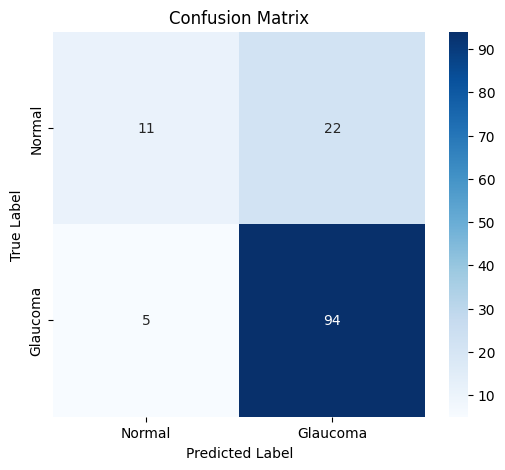

Predictions saved to test_predictions.csv


In [21]:
import pandas as pd 
import numpy as np 
import os 
from PIL import Image 
import tensorflow as tf 
from sklearn.metrics import confusion_matrix, classification_report 
import matplotlib.pyplot as plt 
import seaborn as sns 
# Load trained model 
model = tf.keras.models.load_model("glaucoma_model.h5") 
# Load test dataset 
test_df = pd.read_csv("test_dataset.csv") 
image_folder = "images_resized" 
X_test, y_test = [], [] 
for index, row in test_df.iterrows(): 
    img_path = os.path.join(image_folder, row["Image Name"]) 
    img = Image.open(img_path) 
    img_array = np.array(img) / 255.0 
    X_test.append(img_array) 
    y_test.append(row["label_numeric"]) 
X_test = np.array(X_test) 
y_test = np.array(y_test) 
# Generate predictions 
predictions = model.predict(X_test) 
predicted_labels = (predictions > 0.5).astype(int) 
# Confusion matrix 
cm = confusion_matrix(y_test, predicted_labels) 
print("Confusion Matrix:") 
print(cm) 
# Classification report 
print("\nClassification Report:") 
print(classification_report(y_test, predicted_labels)) 

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Glaucoma'],
    yticklabels=['Normal', 'Glaucoma'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Save predictions to CSV
test_df["prediction"] = predicted_labels
test_df["probability"] = predictions
test_df.to_csv("test_predictions.csv", index=False)
print("Predictions saved to test_predictions.csv")



Script 23: Visualize predictions

Total test images loaded: 132


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7401c739d800> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step

Displaying first 10 predictions...


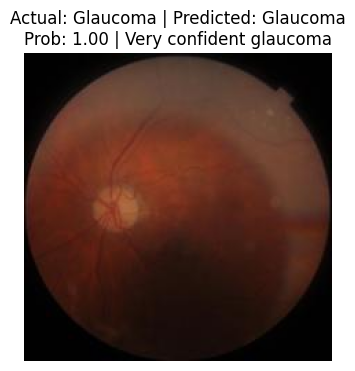

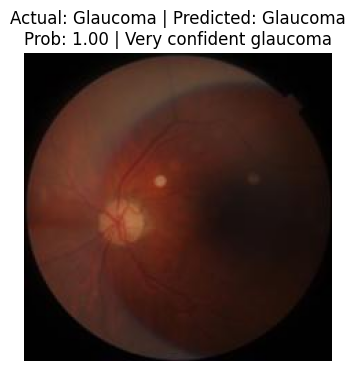

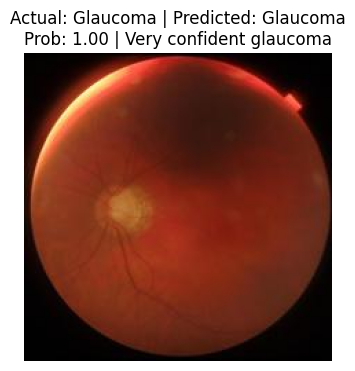

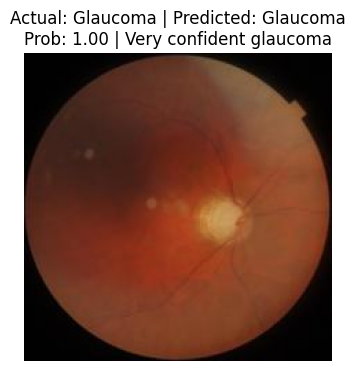

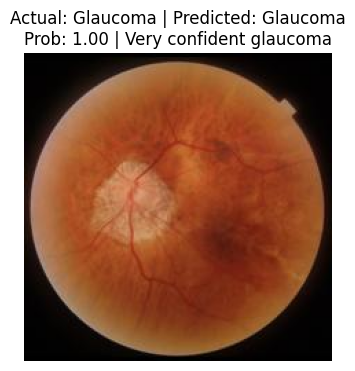

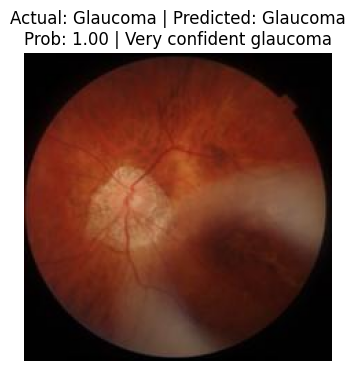

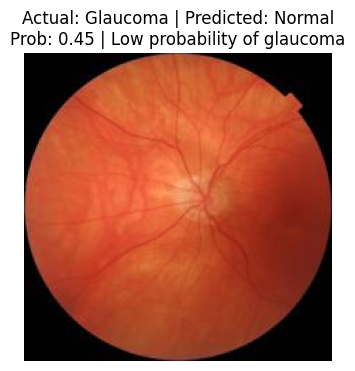

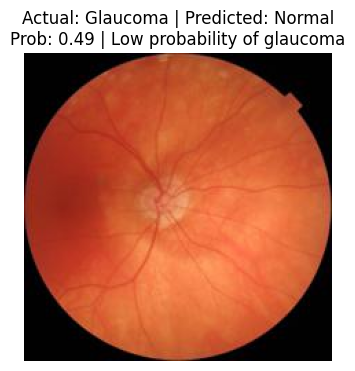

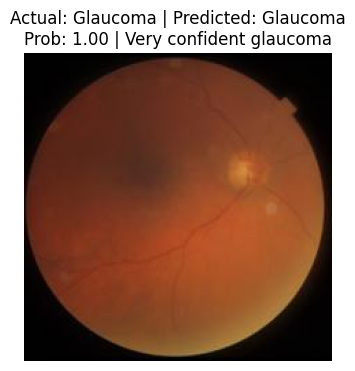

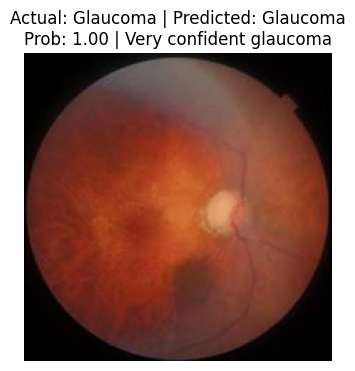

Number of incorrect predictions: 27

Displaying first 5 incorrect predictions...


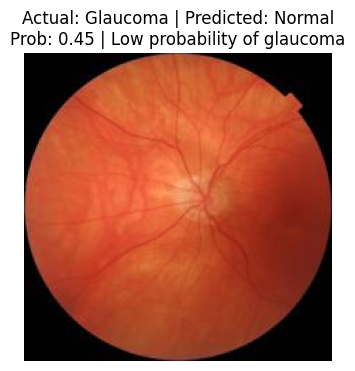

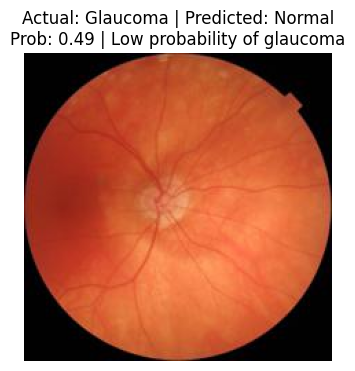

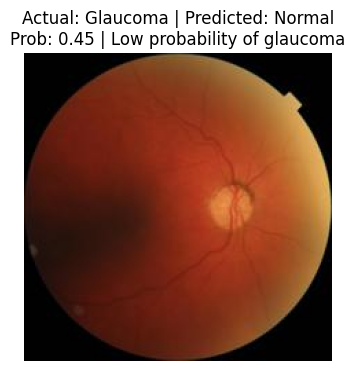

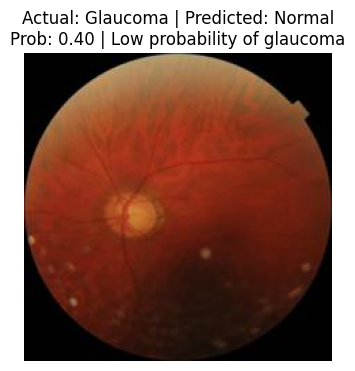

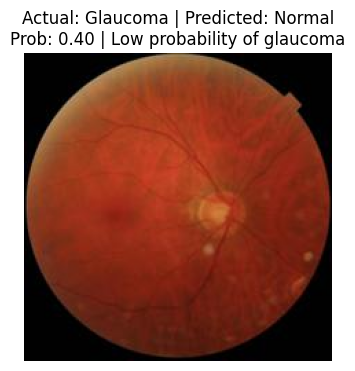


Displaying 5 random predictions...


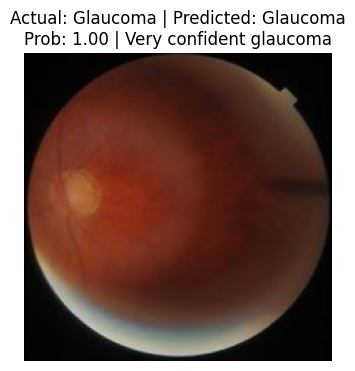

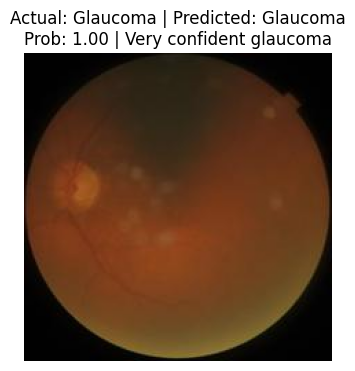

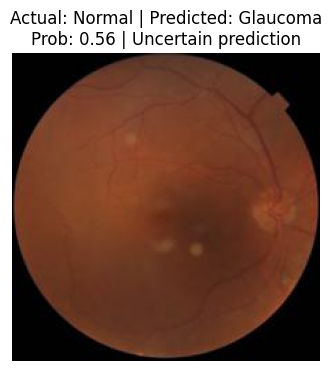

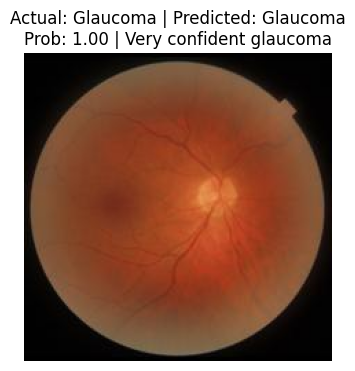

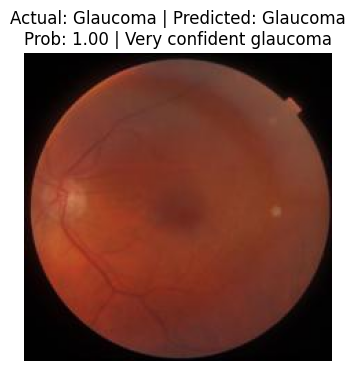

In [23]:
import pandas as pd
import numpy as np
import os
import random
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt

# ===============================
# 1. LOAD TRAINED MODEL
# ===============================
model = tf.keras.models.load_model("glaucoma_model.h5")

# ===============================
# 2. LOAD TEST DATASET
# ===============================
test_df = pd.read_csv("test_dataset.csv")
image_folder = "images_resized"

# ===============================
# 3. PREPARE TEST IMAGES
# ===============================
X_test = []
y_test = []
valid_image_names = []

for _, row in test_df.iterrows():
    image_path = os.path.join(image_folder, row["Image Name"])

    if os.path.exists(image_path):
        img = Image.open(image_path).convert("RGB")
        img = img.resize((224, 224))
        img_array = np.array(img) / 255.0
        X_test.append(img_array)
        y_test.append(row["label_numeric"])
        valid_image_names.append(row["Image Name"])
    else:
        print(f"Missing image: {image_path}")

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Total test images loaded:", len(X_test))

# ===============================
# 4. GENERATE PREDICTIONS
# ===============================
predictions = model.predict(X_test)
predicted_labels = (predictions > 0.5).astype(int)

# ===============================
# 5. LABEL MAPPING
# ===============================
label_map = {1: "Glaucoma", 0: "Normal"}

# ===============================
# 6. PROBABILITY INTERPRETATION
# ===============================
def interpret_probability(prob):
    if prob >= 0.95:
        return "Very confident glaucoma"
    elif prob >= 0.70:
        return "Moderate confidence"
    elif prob >= 0.52:
        return "Uncertain prediction"
    else:
        return "Low probability of glaucoma"

# ===============================
# 7. DISPLAY FIRST 10 PREDICTIONS
# ===============================
print("\nDisplaying first 10 predictions...")

num_display = min(10, len(X_test))

for i in range(num_display):
    image_path = os.path.join(image_folder, valid_image_names[i])
    img = Image.open(image_path)

    actual = y_test[i]
    predicted = predicted_labels[i][0]
    probability = predictions[i][0]

    actual_text = label_map[actual]
    pred_text = label_map[predicted]
    confidence_text = interpret_probability(probability)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(
        f"Actual: {actual_text} | Predicted: {pred_text}\n"
        f"Prob: {probability:.2f} | {confidence_text}"
    )
    plt.axis("off")
    plt.show()
# ===============================
# 8. IDENTIFY INCORRECT PREDICTIONS
# ===============================
incorrect_indices = np.where(predicted_labels.flatten() != y_test)[0]
print("Number of incorrect predictions:", len(incorrect_indices))

# ===============================
# 9. VISUALIZE FIRST 5 INCORRECT PREDICTIONS
# ===============================
print("\nDisplaying first 5 incorrect predictions...")

num_incorrect_display = min(5, len(incorrect_indices))

for idx in incorrect_indices[:num_incorrect_display]:
    image_path = os.path.join(image_folder, valid_image_names[idx])
    img = Image.open(image_path)

    actual = y_test[idx]
    predicted = predicted_labels[idx][0]
    probability = predictions[idx][0]

    actual_text = label_map[actual]
    pred_text = label_map[predicted]
    confidence_text = interpret_probability(probability)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(
        f"Actual: {actual_text} | Predicted: {pred_text}\n"
        f"Prob: {probability:.2f} | {confidence_text}"
    )
    plt.axis("off")
    plt.show()

# ===============================
# 10. SHOW 5 RANDOM PREDICTIONS
# ===============================
print("\nDisplaying 5 random predictions...")

random_count = min(5, len(X_test))
random_indices = random.sample(range(len(X_test)), random_count)

for idx in random_indices:
    image_path = os.path.join(image_folder, valid_image_names[idx])
    img = Image.open(image_path)

    actual = y_test[idx]
    predicted = predicted_labels[idx][0]
    probability = predictions[idx][0]

    actual_text = label_map[actual]
    pred_text = label_map[predicted]
    confidence_text = interpret_probability(probability)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(
        f"Actual: {actual_text} | Predicted: {pred_text}\n"
        f"Prob: {probability:.2f} | {confidence_text}"
    )
    plt.axis("off")
    plt.show()


Script 24: Roc curve and auc score

AUC Score: 0.9379


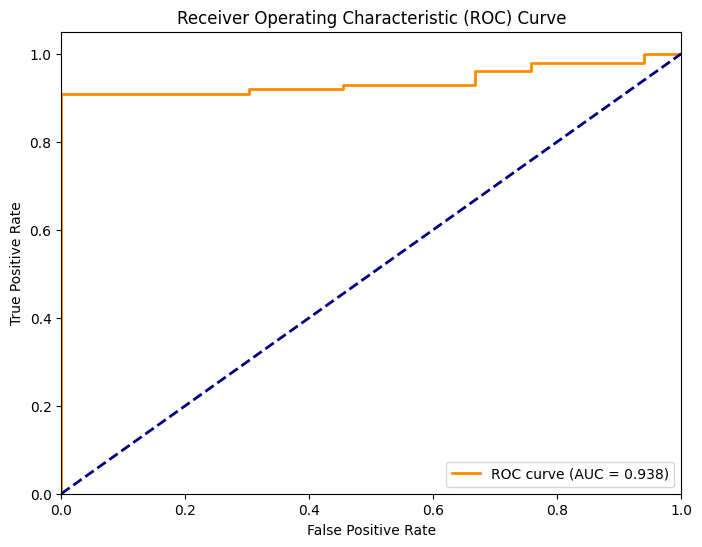

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Calculate FPR, TPR, and Thresholds
fpr, tpr, thresholds = roc_curve(y_test, predictions)

# 2. Calculate AUC Score
roc_auc = auc(fpr, tpr)
print(f"AUC Score: {roc_auc:.4f}")

# 3. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Script 25: Grad-COM, saliency maps and heat map

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


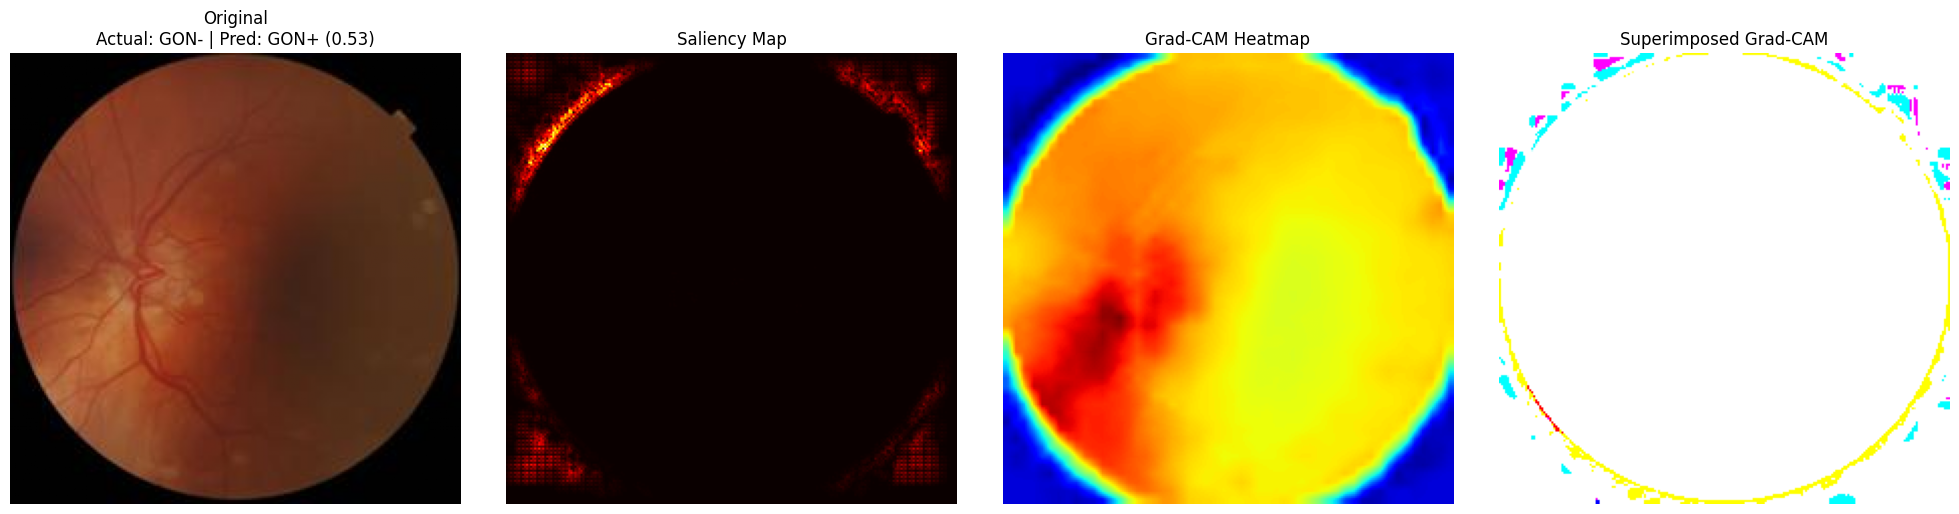

In [30]:
import tensorflow as tf
import numpy as np
import cv2

# --- Function for Saliency Map ---
def generate_saliency_map(model, image):
    # Convert image to tensor and add batch dimension
    image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
    image_tensor = tf.expand_dims(image_tensor, axis=0) 

    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        prediction = model(image_tensor)
        loss = prediction[0][0] # Focus on the probability score
    
    # Calculate gradients of the loss with respect to the input image
    gradients = tape.gradient(loss, image_tensor)
    
    # Take the maximum absolute gradient across the color channels
    saliency = tf.reduce_max(tf.abs(gradients), axis=-1)
    return saliency[0].numpy()

# --- Function for Grad-CAM (Updated for Keras 3) ---
def generate_grad_cam(model, image, layer_name="conv2d_8"):
    image_tensor = np.expand_dims(image, axis=0)
    image_tensor = tf.convert_to_tensor(image_tensor, dtype=tf.float32)
    
    # Dynamically build a functional model to avoid Sequential output errors
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = inputs
    target_output = None
    
    # Pass the input through each layer and grab the target convolution layer's output
    for layer in model.layers:
        x = layer(x)
        if layer.name == layer_name:
            target_output = x
            
    # Our new model outputs both the targeted conv layer and the final prediction
    grad_model = tf.keras.Model(inputs=inputs, outputs=[target_output, x])
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_tensor)
        loss = predictions[:, 0]

    # Extract gradients of the loss with respect to the convolutional feature map
    grads = tape.gradient(loss, conv_outputs)
    
    # Average the gradients spatially
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Multiply each channel in the feature map array by its pooled gradient
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize the heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()
    
    # Resize heatmap to match the original image size
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    return heatmap
# --- Function to Display Everything Together ---
def display_model_interpretability(model, image_idx, X_test, y_test):
    img = X_test[image_idx]
    actual_label = "GON+" if y_test[image_idx] == 1 else "GON-"
    pred_prob = model.predict(np.expand_dims(img, axis=0))[0][0]
    pred_label = "GON+" if pred_prob > 0.5 else "GON-"
    
    saliency = generate_saliency_map(model, img)
    heatmap = generate_grad_cam(model, img, layer_name="conv2d_2")
    
    # Superimpose Grad-CAM heatmap over the original image
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    superimposed_img = np.clip(heatmap_colored * 0.4 + np.uint8(255 * img), 0, 255)
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(img)
    axes[0].set_title(f"Original\nActual: {actual_label} | Pred: {pred_label} ({pred_prob:.2f})")
    axes[0].axis('off')
    
    axes[1].imshow(saliency, cmap='hot')
    axes[1].set_title("Saliency Map")
    axes[1].axis('off')
    
    axes[2].imshow(heatmap, cmap='jet')
    axes[2].set_title("Grad-CAM Heatmap")
    axes[2].axis('off')
    
    axes[3].imshow(superimposed_img)
    axes[3].set_title("Superimposed Grad-CAM")
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()

# 3. Test on a random image from the test set
import random
random_idx = random.randint(0, len(X_test) - 1)
display_model_interpretability(model, random_idx, X_test, y_test)